In [1]:
!pip uninstall -y jax jaxlib jax_cuda12_plugin


Found existing installation: jax 0.7.2
Uninstalling jax-0.7.2:
  Successfully uninstalled jax-0.7.2
Found existing installation: jaxlib 0.7.2
Uninstalling jaxlib-0.7.2:
  Successfully uninstalled jaxlib-0.7.2
Found existing installation: jax-cuda12-plugin 0.7.2
Uninstalling jax-cuda12-plugin-0.7.2:
  Successfully uninstalled jax-cuda12-plugin-0.7.2


In [2]:
!rm -rf /usr/local/lib/python3.12/dist-packages/jax*
!rm -rf /usr/local/lib/python3.12/dist-packages/jaxlib*
!rm -rf /usr/local/lib/python3.12/dist-packages/jax_plugins*


In [3]:
!pip install --no-cache-dir "jax==0.4.30" "jaxlib==0.4.30"
!pip install --no-cache-dir "flax==0.10.1" "optax==0.2.6"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.7/79.7 MB 84.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
orbax-checkpoint 0.11.30 requires jax>=0.6.0, but you have jax 0.4.30 which is incompatible.
optax 0.2.6 requires jax>=0.5.3, but you have jax 0.4.30 which is incompatible.
optax 0.2.6 requires jaxlib>=0.5.3, but you have jaxlib 0.4.30 which is incompatible.
flax 0.10.7 requires jax>=0.6.0, but you have jax 0.4.30 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.3/419.3 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 68.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 MB 209.8 MB/s eta 0:00:00
  Attempting uninstall: jaxlib
    Found existing installation: jaxlib 0.4.30
    Uninstallin

In [4]:
!mkdir -p project3-stock-transformer/src
!mkdir -p project3-stock-transformer/data/raw
!mkdir -p project3-stock-transformer/data/processed
!mkdir -p project3-stock-transformer/experiments/checkpoints


In [5]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
ticker_path = "/content/drive/MyDrive/stock_market_data/nasdaq/csv/AMZN.csv"


In [7]:

!git clone https://github.com/Under-the-stars/Time-Series-Forecasting-with-Transformers-.git

Cloning into 'Time-Series-Forecasting-with-Transformers-'...
remote: Enumerating objects: 85, done.
remote: Counting objects: 100% (85/85), done.
remote: Compressing objects: 100% (82/82), done.
remote: Total 85 (delta 39), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (85/85), 204.92 KiB | 2.23 MiB/s, done.
Resolving deltas: 100% (39/39), done.


In [8]:
!ls Time-Series-Forecasting-with-Transformers-

baseline.py  eval.py		   model.py   train.py
data.py      FLAX.API.ipynb.ipynb  README.md


In [9]:
import sys
sys.path.append("/content/Time-Series-Forecasting-with-Transformers-")


In [10]:
!pip install flax optax jax jaxlib --upgrade
!pip install numpy pandas matplotlib scikit-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 488.2/488.2 kB 7.2 MB/s eta 0:00:00
  Attempting uninstall: flax
    Found existing installation: flax 0.10.1
    Uninstalling flax-0.10.1:
      Successfully uninstalled flax-0.10.1


In [11]:
!mkdir -p /content/Time-Series-Forecasting-with-Transformers-/src


In [12]:
!mv /content/Time-Series-Forecasting-with-Transformers-/data.py /content/Time-Series-Forecasting-with-Transformers-/src
!mv /content/Time-Series-Forecasting-with-Transformers-/train.py /content/Time-Series-Forecasting-with-Transformers-/src
!mv /content/Time-Series-Forecasting-with-Transformers-/eval.py /content/Time-Series-Forecasting-with-Transformers-/src
!mv /content/Time-Series-Forecasting-with-Transformers-/model.py /content/Time-Series-Forecasting-with-Transformers-/src
!mv /content/Time-Series-Forecasting-with-Transformers-/baseline.py /content/Time-Series-Forecasting-with-Transformers-/src


In [13]:
!sed -n '1,200p' /content/Time-Series-Forecasting-with-Transformers-/src/data.py


import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler


# ============================================================
# LOAD AMZN CSV FILE
# ============================================================
def load_ticker_csv(path):
    df = pd.read_csv(path)
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df = df.sort_values("Date").set_index("Date")
    return df


# ============================================================
# CREATE 5-STEP FUTURE TARGETS FROM CLOSE PRICE
# ============================================================
def create_price_targets(df, horizon=5):
    """
    horizon = number of future steps (e.g., next 5 days)
    Returns: y shape = (num_samples, horizon)
    """

    close = df["Close"].values
    y = []

    for i in range(len(close) - horizon):
        y.append(close[i+1 : i+1+horizon])

    return np.array(y)


# ============================================================
# CREATE INPUT WINDOWS (X) USI

In [14]:
import sys, importlib
sys.path.append("/content/Time-Series-Forecasting-with-Transformers-/src")

import data
importlib.reload(data)

X_train, y_train, X_val, y_val, X_test, y_test, scaler = \
    data.prepare_dataset(ticker_path, seq_len=60, horizon=5)


🔹 Loading AMZN data...
🔹 Creating future targets...
🔹 Aligning features with targets...
🔹 Scaling features and targets...
🔹 Building sliding windows...
🔹 Splitting dataset (70/10/20)...
✅ AMZN dataset ready!
Train: (4461, 60, 6), Val: (637, 60, 6), Test: (1275, 60, 6)


/content/Time-Series-Forecasting-with-Transformers-/src/data.py:11: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Date"] = pd.to_datetime(df["Date"], errors="coerce")


In [15]:
import sys, importlib
sys.path.append("/content/Time-Series-Forecasting-with-Transformers-/src")

import data
importlib.reload(data)

from data import prepare_dataset

X_train, y_train, X_val, y_val, X_test, y_test, scaler = prepare_dataset(
    ticker_path,
    seq_len=60,
    horizon=5
)

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)


🔹 Loading AMZN data...
🔹 Creating future targets...
🔹 Aligning features with targets...
🔹 Scaling features and targets...
🔹 Building sliding windows...
🔹 Splitting dataset (70/10/20)...
✅ AMZN dataset ready!
Train: (4461, 60, 6), Val: (637, 60, 6), Test: (1275, 60, 6)
(4461, 60, 6) (4461, 5)
(637, 60, 6) (637, 5)
(1275, 60, 6) (1275, 5)


/content/Time-Series-Forecasting-with-Transformers-/src/data.py:11: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Date"] = pd.to_datetime(df["Date"], errors="coerce")


In [16]:
import sys, importlib
sys.path.append("/content/Time-Series-Forecasting-with-Transformers-/src")

import model
importlib.reload(model)

import train
importlib.reload(train)


<module 'train' from '/content/Time-Series-Forecasting-with-Transformers-/src/train.py'>

In [17]:
import importlib, train
importlib.reload(train)

from train import train_model


In [18]:
import sys, importlib
sys.path.insert(0, "/content/Time-Series-Forecasting-with-Transformers-/src")

import model
importlib.reload(model)

from model import TimeSeriesTransformer

print("MODEL CLASS:", TimeSeriesTransformer)


MODEL CLASS: <class 'model.TimeSeriesTransformer'>


In [19]:
import inspect
print(inspect.getsource(model.TimeSeriesTransformer))


class TimeSeriesTransformer(nn.Module):
    seq_len: int = 60
    d_model: int = 128
    num_heads: int = 4
    num_layers: int = 4
    mlp_dim: int = 256
    out_len: int = 5
    num_features: int = 6   # ← MATCH THE CHECKPOINT (6 FEATURES)

    @nn.compact
    def __call__(self, x, train=True):

        # x shape must be (batch, seq_len, 6)
        x = nn.Dense(self.d_model)(x)

        x = PositionalEncoding(self.d_model)(x)

        for _ in range(self.num_layers):
            x = TransformerBlock(
                self.d_model,
                self.num_heads,
                self.mlp_dim
            )(x, train=train)

        last = x[:, -1]
        return nn.Dense(self.out_len)(last)



In [20]:
import inspect
print(inspect.getsource(train.TimeSeriesTransformer))


class TimeSeriesTransformer(nn.Module):
    seq_len: int = 60
    d_model: int = 128
    num_heads: int = 4
    num_layers: int = 4
    mlp_dim: int = 256
    out_len: int = 5
    num_features: int = 6   # ← MATCH THE CHECKPOINT (6 FEATURES)

    @nn.compact
    def __call__(self, x, train=True):

        # x shape must be (batch, seq_len, 6)
        x = nn.Dense(self.d_model)(x)

        x = PositionalEncoding(self.d_model)(x)

        for _ in range(self.num_layers):
            x = TransformerBlock(
                self.d_model,
                self.num_heads,
                self.mlp_dim
            )(x, train=train)

        last = x[:, -1]
        return nn.Dense(self.out_len)(last)



In [21]:
!mkdir /content/checkpoints

In [22]:
import sys
for m in list(sys.modules.keys()):
    if "model" in m or "train" in m or "eval" in m:
        del sys.modules[m]

import importlib
import model, train, eval
importlib.reload(model)
importlib.reload(train)
importlib.reload(eval)


<module 'eval' from '/content/Time-Series-Forecasting-with-Transformers-/src/eval.py'>

In [23]:
!rm -rf /content/checkpoints
!rm -rf /content/checkpoints_multi
!rm -rf checkpoints
!rm -rf checkpoints_multi


In [24]:
print(X_train.shape)


(4461, 60, 6)


In [25]:
import shutil
shutil.rmtree("/content/checkpoints_single", ignore_errors=True)


In [26]:
import sys, importlib
sys.modules.pop("train", None)
import train
importlib.reload(train)
from train import train_model


In [42]:
state = train.train_model(
    X_train, y_train,
    X_val, y_val,
    seq_len=60,
    out_len=5,
    num_features=6,
    batch_size=64,
    epochs=40,
    learning_rate=1e-3,
    ckpt_dir="/content/checkpoints_single"
)



Epoch 1/40


Train Loss: 0.075179 | Val Loss: 0.173960
✔ New best checkpoint saved!

Epoch 2/40


Train Loss: 0.003201 | Val Loss: 0.115094
✔ New best checkpoint saved!

Epoch 3/40


Train Loss: 0.003735 | Val Loss: 0.107986
✔ New best checkpoint saved!

Epoch 4/40


Train Loss: 0.003921 | Val Loss: 0.074479
✔ New best checkpoint saved!

Epoch 5/40
Train Loss: 0.002317 | Val Loss: 0.076729

Epoch 6/40


...

Train Loss: 0.000429 | Val Loss: 0.009343
✔ New best checkpoint saved!

Epoch 16/40
Train Loss: 0.000199 | Val Loss: 0.012862

Epoch 17/40


Train Loss: 0.000578 | Val Loss: 0.009052
✔ New best checkpoint saved!

Epoch 18/40


Train Loss: 0.000258 | Val Loss: 0.008804
✔ New best checkpoint saved!

Epoch 19/40


Train Loss: 0.000424 | Val Loss: 0.008264
✔ New best checkpoint saved!

Epoch 20/40
Train Loss: 0.000194 | Val Loss: 0.009219

Epoch 21/40
Train Loss: 0.000233 | Val Loss: 0.009553

Epoch 22/40
Train Loss: 0.000294 | Val Loss: 0.008951

Epoch 23/40


Train Loss: 0.000210 | Val Loss: 0.007280
✔ New best checkpoint saved!

Epoch 24/40
Train Loss: 0.000275 | Val Loss: 0.008782

Epoch 25/40
Train Loss: 0.000232 | Val Loss: 0.008032

Epoch 26/40
Train Loss: 0.000174 | Val Loss: 0.007880

Epoch 27/40
Train Loss: 0.000258 | Val Loss: 0.009960

Epoch 28/40
Train Loss: 0.000316 | Val Loss: 0.013305

Epoch 29/40
Train Loss: 0.000265 | Val Loss: 0.010020

Epoch 30/40
Train Loss: 0.000219 | Val Loss: 0.015380

Epoch 31/40
Train Loss: 0.000206 | Val Loss: 0.009814

Epoch 32/40
Train Loss: 0.000243 | Val Loss: 0.008965

Epoch 33/40
Train Loss: 0.000248 | Val Loss: 0.012810

Epoch 34/40
Train Loss: 0.000296 | Val Loss: 0.009627

Epoch 35/40
Train Loss: 0.000164 | Val Loss: 0.016218

Epoch 36/40
Train Loss: 0.000145 | Val Loss: 0.014374

Epoch 37/40
Train Loss: 0.000166 | Val Loss: 0.011893

Epoch 38/40
Train Loss: 0.000209 | Val Loss: 0.020863

Epoch 39/40
Train Loss: 0.000147 | Val Loss: 0.018602

Epoch 40/40
Train Loss: 0.000247 | Val Loss: 0.0

testing


Checkpoint restored.
Predictions shape: (1275, 5)
First 5 preds (t+5): [0.2395685  0.24015431 0.23896039 0.24689983 0.23958346]
First 5 true  (t+5): [0.54433645 0.53658989 0.5328577  0.54663639 0.56406359]


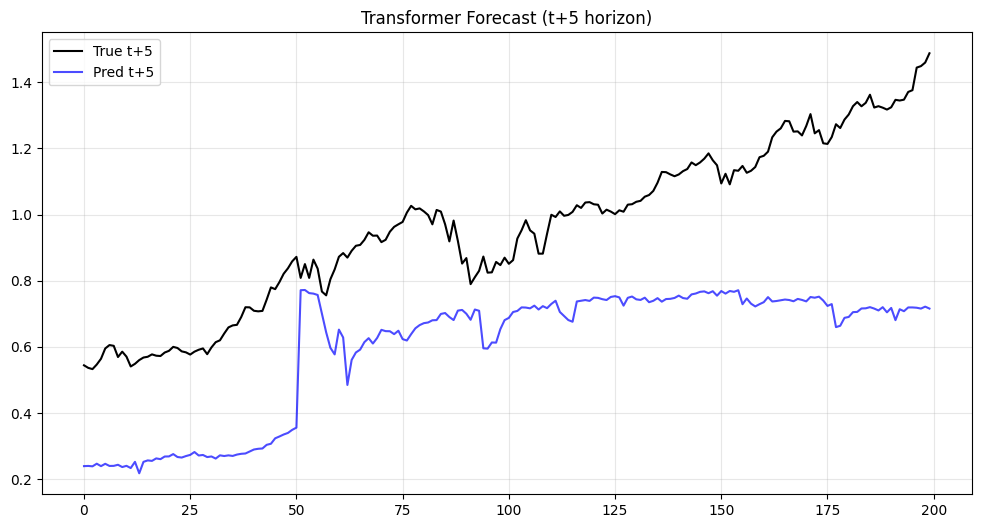

In [43]:
import importlib.util
import jax
import jax.numpy as jnp
from flax.training import checkpoints
import matplotlib.pyplot as plt

# ---------- 1. Load model definition ----------
model_path = "/content/Time-Series-Forecasting-with-Transformers-/src/model.py"

spec = importlib.util.spec_from_file_location("model", model_path)
model_mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(model_mod)

TimeSeriesTransformer = model_mod.TimeSeriesTransformer

# ---------- 2. Rebuild model EXACTLY as in train.py ----------
model = TimeSeriesTransformer(
    seq_len=60,
    d_model=128,
    num_heads=4,
    num_layers=4,
    mlp_dim=256,
    out_len=5,
    num_features=6,   # <- matches data.py (6 features)
)

dummy_X = jnp.ones((1, 60, 6))
params = model.init(jax.random.PRNGKey(0), dummy_X)["params"]

# ---------- 3. Restore checkpoint ----------
ckpt_dir = "/content/checkpoints_single"
params = checkpoints.restore_checkpoint(ckpt_dir, target=params)
print("Checkpoint restored.")

# ---------- 4. Predict on test data ----------
X_test_jax = jnp.array(X_test)
preds = model.apply({"params": params}, X_test_jax, train=False)

print("Predictions shape:", preds.shape)
print("First 5 preds (t+5):", preds[:5, -1])
print("First 5 true  (t+5):", y_test[:5, -1])

# ---------- 5. Plot in *price space* (NO inverse scaling) ----------
plt.figure(figsize=(12, 6))
plt.plot(y_test[:200, -1], label="True t+5", color="black")
plt.plot(preds[:200, -1], label="Pred t+5", color="blue", alpha=0.7)
plt.legend()
plt.title("Transformer Forecast (t+5 horizon)")
plt.grid(alpha=0.3)
plt.show()


In [44]:
import model
print("MODEL LOADED FROM:", model.__file__)


MODEL LOADED FROM: /content/Time-Series-Forecasting-with-Transformers-/src/model.py


In [45]:
import numpy as np

close_index = 3  # "Close" column position in your feature vector

mean_close = scaler.mean_[close_index]
std_close  = scaler.scale_[close_index]

# Inverse transform
preds_real = preds * std_close + mean_close
y_test_real = y_test * std_close + mean_close


In [46]:
import importlib.util
import jax
import jax.numpy as jnp
from flax.training import checkpoints

# ------------------------------
# Load model.py from correct path
# ------------------------------
model_path = "/content/Time-Series-Forecasting-with-Transformers-/src/model.py"

spec = importlib.util.spec_from_file_location("model", model_path)
model_mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(model_mod)

TimeSeriesTransformer = model_mod.TimeSeriesTransformer

# ------------------------------
# Rebuild the model EXACTLY like during training
# ------------------------------
model = TimeSeriesTransformer(
    seq_len=60,
    d_model=128,
    num_heads=4,
    num_layers=4,
    mlp_dim=256,
    out_len=5,
    num_features=6   # IMPORTANT — matches training
)

# ------------------------------
# Initialize dummy params for shape
# ------------------------------
dummy_X = jnp.ones((1, 60, 6))
params = model.init(jax.random.PRNGKey(0), dummy_X)["params"]

# ------------------------------
# Load checkpoint
# ------------------------------
ckpt_dir = "/content/checkpoints_single"
params = checkpoints.restore_checkpoint(ckpt_dir, target=params)

print("Checkpoint loaded successfully!")

# ------------------------------
# Run predictions on test data
# ------------------------------
X_test_jax = jnp.array(X_test)
preds = model.apply({"params": params}, X_test_jax, train=False)

print("Predictions generated! Shape:", preds.shape)


Checkpoint loaded successfully!
Predictions generated! Shape: (1275, 5)


In [47]:
!find /content -maxdepth 4 -name "model.py"


/content/Time-Series-Forecasting-with-Transformers-/src/model.py


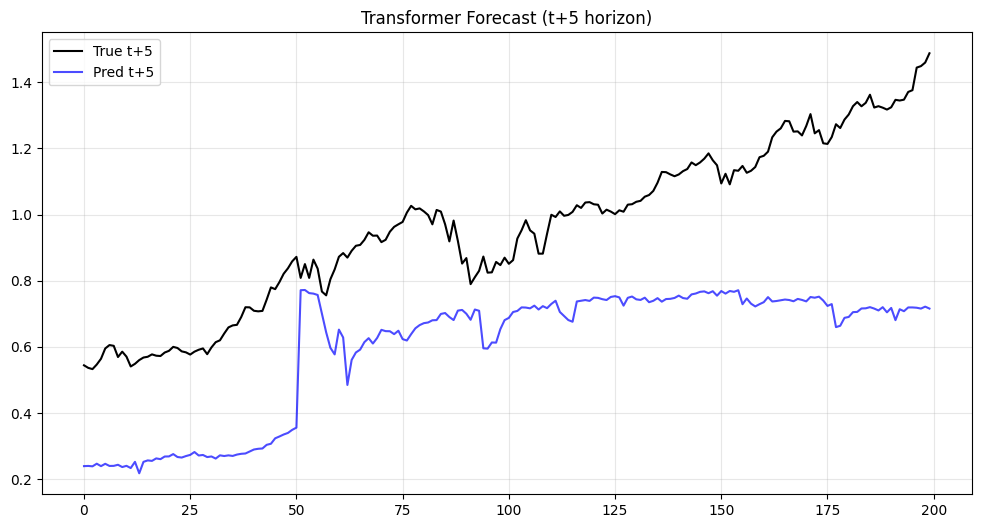

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(y_test[:200, -1], label="True t+5", color="black")
plt.plot(preds[:200, -1], label="Pred t+5", color="blue", alpha=0.7)
plt.legend()
plt.title("Transformer Forecast (t+5 horizon)")
plt.grid(alpha=0.3)
plt.show()


In [49]:
import inspect, model
print(inspect.getsource(model.TimeSeriesTransformer))


class TimeSeriesTransformer(nn.Module):
    seq_len: int = 60
    d_model: int = 128
    num_heads: int = 4
    num_layers: int = 4
    mlp_dim: int = 256
    out_len: int = 5
    num_features: int = 6   # ← MATCH THE CHECKPOINT (6 FEATURES)

    @nn.compact
    def __call__(self, x, train=True):

        # x shape must be (batch, seq_len, 6)
        x = nn.Dense(self.d_model)(x)

        x = PositionalEncoding(self.d_model)(x)

        for _ in range(self.num_layers):
            x = TransformerBlock(
                self.d_model,
                self.num_heads,
                self.mlp_dim
            )(x, train=train)

        last = x[:, -1]
        return nn.Dense(self.out_len)(last)



In [50]:
import sys, importlib

sys.path.insert(0, "/content/Time-Series-Forecasting-with-Transformers-/src")

import model, train, eval
importlib.reload(model)
importlib.reload(train)
importlib.reload(eval)


<module 'eval' from '/content/Time-Series-Forecasting-with-Transformers-/src/eval.py'>

In [51]:
from eval import load_model

model_loaded, params = load_model(
    ckpt_dir="/content/checkpoints_single",
    seq_len=60,
    out_len=5,
    num_features=6
)


🔹 Loading trained model...


✔ Checkpoint loaded.


In [52]:
from eval import predict

y_pred = predict(model_loaded, params, X_test)

print("Predictions shape:", y_pred.shape)


Predictions shape: (1275, 5)


In [53]:
from eval import compute_metrics

metrics = compute_metrics(y_test, y_pred)

for k, v in metrics.items():
    print(f"{k}: {v:.6f}")


MAE_h1: 1.558764
RMSE_h1: 1.764912
MAE_h2: 1.117064
RMSE_h2: 1.356404
MAE_h3: 1.398215
RMSE_h3: 1.555588
MAE_h4: 1.175330
RMSE_h4: 1.347573
MAE_h5: 1.218692
RMSE_h5: 1.462351


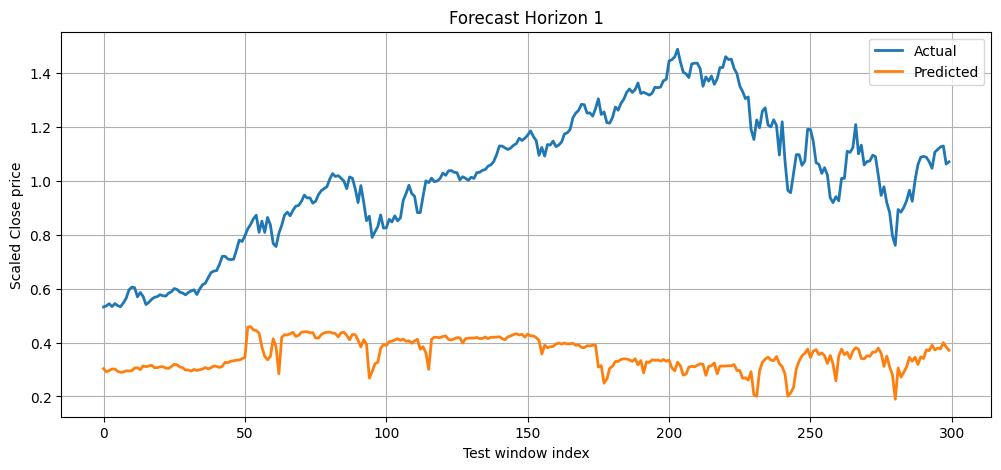

In [54]:
from eval import plot_horizon

plot_horizon(
    y_true=y_test,
    y_pred=y_pred,
    horizon=1,      # next-day return
    num_points=300
)


In [55]:
print("Mean true return:", y_test.mean())
print("Mean predicted return:", y_pred.mean())


Mean true return: 1.8368095109446132
Mean predicted return: 0.54319656
